In [1]:
# ==================== 环境配置 ====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
from datetime import datetime
import os

In [2]:
# ================ 全局变量 ================
SITE_ID = "Cockatoo"                
BUILDING_TYPE = "office"       
TARGET =  f"{SITE_ID}_{BUILDING_TYPE}_Giovanni"  # 明确目标列名称
DATA_SAVE_PATH = "E:/bishe/preprocessed_data（Cockatoo）.csv"  # 确保路径正确 

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)   

Using device: cpu

3折时序交叉验证（包含训练集和验证集）
测试集保持不动防止数据泄露

开始 3 折时序交叉验证...
注意：包含训练集和验证集，测试集保持不动防止数据泄露
交叉验证总数据量: (9493, 24, 18)

--- 训练第 1/3 折 ---
训练集大小: (2374, 24, 18), 验证集大小: (2373, 24, 18)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_17476\2161932933.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')
E:\python数据\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


fold_1 - 早停在第 37 轮
第 1 折结果 - RMSE: 0.2064, MAE: 0.1518, R²: 0.5067

--- 训练第 2/3 折 ---
训练集大小: (4747, 24, 18), 验证集大小: (2373, 24, 18)


E:\python数据\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


第 2 折结果 - RMSE: 0.0516, MAE: 0.0387, R²: 0.6612

--- 训练第 3/3 折 ---
训练集大小: (7120, 24, 18), 验证集大小: (2373, 24, 18)


...

Epoch 98: Train Loss=0.0055, Val Loss=0.0089


Epoch 99: 100%|███████████████████████████████████████████████████████████| 59/59 [00:02<00:00, 26.24it/s, loss=0.0078]


Epoch 99: Train Loss=0.0056, Val Loss=0.0088


Epoch 100: 100%|██████████████████████████████████████████████████████████| 59/59 [00:02<00:00, 26.41it/s, loss=0.0050]


Epoch 100: Train Loss=0.0055, Val Loss=0.0085


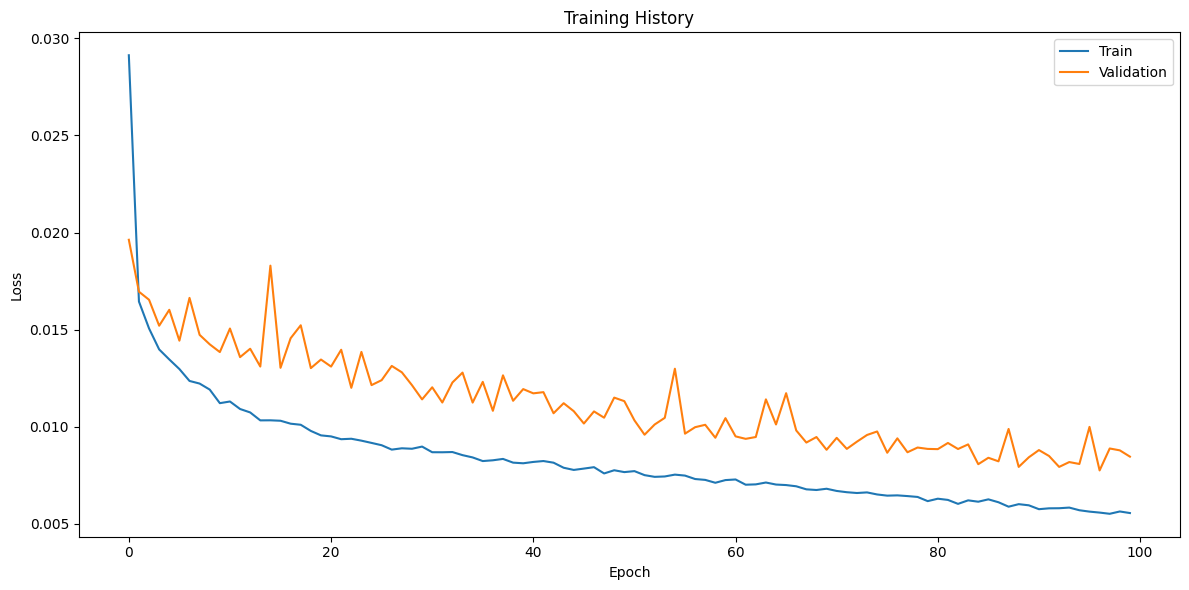

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17476\2161932933.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_enhanced_lstm.pth'

成功加载最佳模型

验证集评估结果:
Validation - MSE: 36.71, RMSE: 6.06, CVRMSE: 25.02%, R2: 0.8578, Accuracy: 81.54%


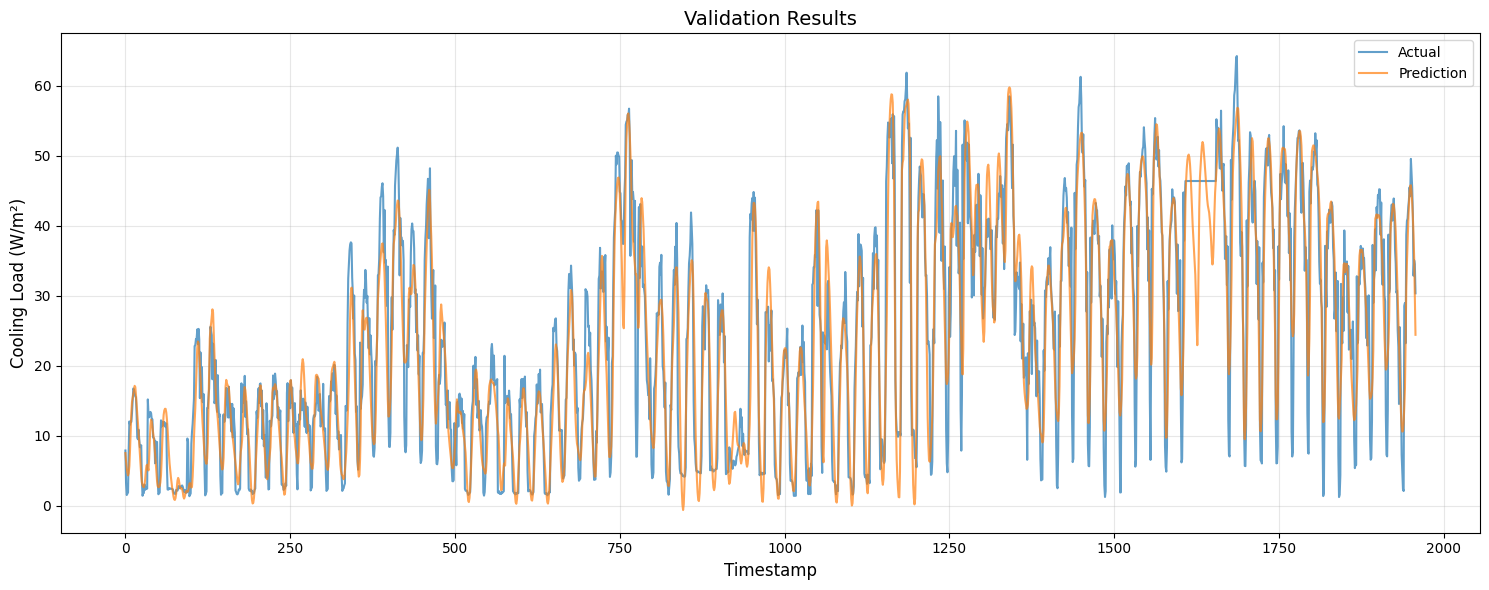


测试集评估结果:
Test - MSE: 30.58, RMSE: 5.53, CVRMSE: 19.44%, R2: 0.8472, Accuracy: 84.93%

Test Set Date Range:
Start: 2017-09-11 01:00
End: 2017-09-15 23:00
Days: 5 days (Mon, Tue, Wed, Thu, Fri)
Total hours: 118


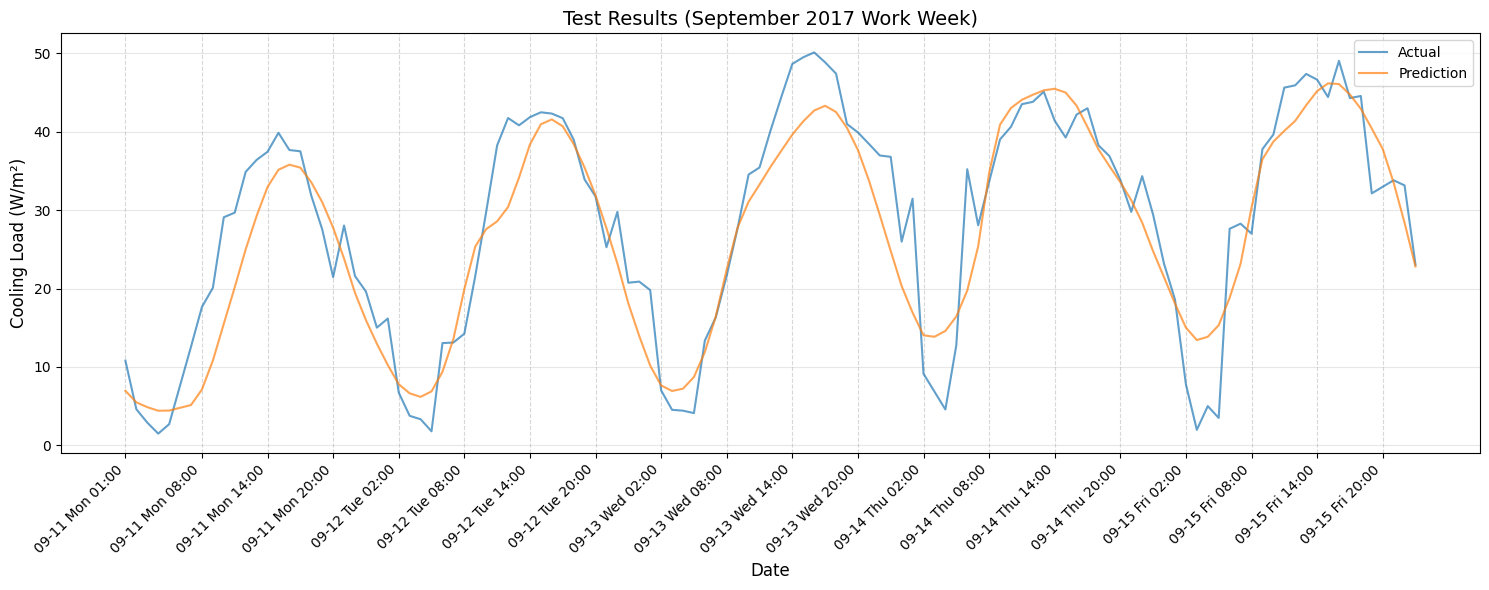

LSTM Model saved to 'E:/bishe/lstm_model.pth'


In [3]:
# ==================== 辅助函数 ====================
def fill_lag_nan(df, ref_df, target_col):
    """精确填充滞后特征中的NaN值"""
    for col in df.columns:
        if 'lag_' in col:
            lag = int(col.split('_')[-1])
            # 使用参考数据集最后lag个有效值填充
            if not ref_df.empty:
                last_valid = ref_df[target_col].iloc[-lag:].dropna()
                if not last_valid.empty:
                    fill_value = last_valid.mean()
                else:
                    fill_value = 0  # 回退值
            else:
                fill_value = 0
            df[col] = df[col].fillna(fill_value)
    return df

def clean_data(df):
    """数据清洗函数"""
    # 填充NaN
    df = df.fillna(method='ffill').fillna(method='bfill')
    
    # 处理无穷大值
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].mean())
    return df 

# ==================== 3折交叉验证函数 ====================
def time_series_cross_validation(X_train_seq, y_train_seq, X_val_seq, y_val_seq, window_size, device, n_splits=3):
    """执行3折时序交叉验证，包含训练集和验证集，测试集不动"""
    print(f"\n开始 {n_splits} 折时序交叉验证...")
    print("注意：包含训练集和验证集，测试集保持不动防止数据泄露")
    
    # 合并训练集和验证集用于交叉验证
    X_all = np.concatenate([X_train_seq, X_val_seq], axis=0)
    y_all = np.concatenate([y_train_seq, y_val_seq], axis=0)
    
    print(f"交叉验证总数据量: {X_all.shape}")
    
    # 创建时序交叉验证分割器
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # 存储每折的结果
    fold_results = {
        'val_rmse': [],
        'val_mae': [],
        'val_r2': [],
        'train_size': [],
        'val_size': []
    }
    
    fold = 1
    for train_idx, val_idx in tscv.split(X_all):
        print(f"\n--- 训练第 {fold}/{n_splits} 折 ---")
        
        # 划分当前折的数据
        X_train_fold = X_all[train_idx]
        y_train_fold = y_all[train_idx]
        X_val_fold = X_all[val_idx]
        y_val_fold = y_all[val_idx]
        
        print(f"训练集大小: {X_train_fold.shape}, 验证集大小: {X_val_fold.shape}")
        fold_results['train_size'].append(X_train_fold.shape[0])
        fold_results['val_size'].append(X_val_fold.shape[0])
        
        # 创建DataLoader
        batch_size = 128
        train_dataset = TensorDataset(torch.FloatTensor(X_train_fold), torch.FloatTensor(y_train_fold))
        val_dataset = TensorDataset(torch.FloatTensor(X_val_fold), torch.FloatTensor(y_val_fold))
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # 初始化模型
        input_size = X_train_fold.shape[2]
        model = EnhancedLSTM(input_size=input_size).to(device)
        
        # 训练当前折的模型
        fold_history = train_single_fold(model, train_loader, val_loader, device, f"fold_{fold}")
        
        # 评估当前折
        fold_val_results = evaluate_single_fold(model, val_loader, device)
        
        # 保存结果
        fold_results['val_rmse'].append(fold_val_results['rmse'])
        fold_results['val_mae'].append(fold_val_results['mae'])
        fold_results['val_r2'].append(fold_val_results['r2'])
        
        print(f"第 {fold} 折结果 - RMSE: {fold_val_results['rmse']:.4f}, MAE: {fold_val_results['mae']:.4f}, R²: {fold_val_results['r2']:.4f}")
        
        fold += 1
    
    # 计算平均性能
    print(f"\n=== 交叉验证结果汇总 ===")
    print(f"平均训练集大小: {np.mean(fold_results['train_size']):.0f} (±{np.std(fold_results['train_size']):.0f})")
    print(f"平均验证集大小: {np.mean(fold_results['val_size']):.0f} (±{np.std(fold_results['val_size']):.0f})")
    print(f"平均验证RMSE: {np.mean(fold_results['val_rmse']):.4f} (±{np.std(fold_results['val_rmse']):.4f})")
    print(f"平均验证MAE: {np.mean(fold_results['val_mae']):.4f} (±{np.std(fold_results['val_mae']):.4f})")
    print(f"平均验证R²: {np.mean(fold_results['val_r2']):.4f} (±{np.std(fold_results['val_r2']):.4f})")
    
    # 输出每折详细结果
    print(f"\n各折详细结果:")
    for i in range(n_splits):
        print(f"  折 {i+1}: 训练集={fold_results['train_size'][i]}, 验证集={fold_results['val_size'][i]}, "
              f"RMSE={fold_results['val_rmse'][i]:.4f}, R²={fold_results['val_r2'][i]:.4f}")
    
    return fold_results

def train_single_fold(model, train_loader, val_loader, device, fold_name, num_epochs=50):
    """训练单个折的模型"""
    optimizer = optim.RMSprop(model.parameters(), lr=0.0001)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15, verbose=False)
    criterion = nn.MSELoss()
    
    history = {'train': [], 'val': []}
    best_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # 训练阶段
        model.train()
        train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            if torch.isnan(loss):
                print(f"{fold_name} - NaN损失出现在第 {epoch+1} 轮")
                return history
                
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            
            train_loss += loss.item()
        
        # 验证阶段
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        
        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train'].append(avg_train)
        history['val'].append(avg_val)
        
        # 学习率调整
        scheduler.step(avg_val)
        
        # 早停检查
        if avg_val < best_loss:
            best_loss = avg_val
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                print(f'{fold_name} - 早停在第 {epoch+1} 轮')
                break
    
    return history

def evaluate_single_fold(model, data_loader, device):
    """评估单个折的模型"""
    model.eval()
    preds, trues = [], []
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).cpu().numpy()
            preds.extend(outputs)
            trues.extend(targets.numpy())
    
    preds = np.array(preds).flatten()
    trues = np.array(trues).flatten()
    
    rmse = math.sqrt(mean_squared_error(trues, preds))
    mae = mean_absolute_error(trues, preds)
    r2 = r2_score(trues, preds)
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'preds': preds, 'trues': trues}

# ==================== 数据预处理 ====================
def load_and_preprocess(file_path=DATA_SAVE_PATH, window_size=24):
    # 加载数据
    data = pd.read_csv(file_path, parse_dates=['timestamp'])
    
    # 筛选目标建筑数据
    building_columns = [col for col in data.columns 
                       if col.startswith(f"{SITE_ID}_{BUILDING_TYPE}_")]
    other_buildings = [col for col in building_columns if col != TARGET]
    data = data.drop(columns=other_buildings)
    
    # 按月份划分数据集
    data = data.sort_values('timestamp')
    data['year_month'] = data['timestamp'].dt.to_period('M')
    unique_months = data['year_month'].unique().tolist()
    
    # 数据集划分
    train = data[data['year_month'].isin(unique_months[:15])]  # 前15个月
    val = data[data['year_month'].isin(unique_months[15:19])]  # 接下来4个月
    
# ========== 测试集时间范围 ==========
    test_start = pd.Timestamp('2017-09-08 00:00:00')
    test_end = pd.Timestamp('2017-09-16 00:00:00')
    test = data[(data['timestamp'] >= test_start) & (data['timestamp'] < test_end)]
    
    # 保存测试集时间戳
    test_timestamps = test['timestamp'].copy()
    
    # 特征工程
    def add_features(df, target_col):
        df = df.copy()
        # 时间特征
        df['Hour'] = df['timestamp'].dt.hour
        df['DayOfWeek'] = df['timestamp'].dt.dayofweek
        
        # 周期特征
        df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
        df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
        df['Day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
        df['Day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
        
        # 滞后特征 - 只使用[1, 2, 3, 24, 48]
        for i in [1, 2, 3, 24, 48]:
            df[f'lag_{i}'] = df[target_col].shift(i)
            
        # 移动平均特征 - 使用shift(1)避免数据泄露
        df['3h_avg'] = df[target_col].rolling(3, min_periods=1).mean().shift(1)
        df['24h_avg'] = df[target_col].rolling(24, min_periods=1).mean().shift(1)
        
        # 交叉特征
        # 确保天气特征存在
        if 'airTemperature' in df.columns and 'dewTemperature' in df.columns:
            df['temp_humidity_ratio'] = df['airTemperature'] / (df['dewTemperature'] + 1e-6)
        else:
            print("警告: 缺少天气特征，跳过创建交叉特征")
        
        return df.drop(columns=['Hour', 'DayOfWeek', 'year_month'])
    
    # 应用特征工程
    train = add_features(train, TARGET)
    val = add_features(val, TARGET)
    test = add_features(test, TARGET)
    
    # 填充滞后特征缺失值
    val = fill_lag_nan(val, train, TARGET)
    test = fill_lag_nan(test, pd.concat([train, val]), TARGET)
    
    # 定义特征列
    base_features = [
        'airTemperature', 'dewTemperature', 'windSpeed', 'seaLvlPressure', 'occ_sch',
        'Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos',
        'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48',
        '3h_avg', '24h_avg',
        'temp_humidity_ratio'
    ]
    
    # 添加可选特征
    if 'temp_humidity_ratio' in train.columns:
        base_features.append('temp_humidity_ratio')
    
    # 确保特征存在
    features = [f for f in base_features if f in train.columns]
    missing_features = set(base_features) - set(features)
    if missing_features:
        print(f"警告: 以下特征不存在，已移除: {missing_features}")
    
    # 数据清洗
    train = clean_data(train)
    val = clean_data(val)
    test = clean_data(test)
    
    # 数据归一化
    scaler_x = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    # 使用训练集拟合归一化器
    X_train_scaled = scaler_x.fit_transform(train[features])
    y_train_scaled = scaler_y.fit_transform(train[[TARGET]])
    
    # 检查数据有效性
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=1.0, neginf=0.0)
    y_train_scaled = np.nan_to_num(y_train_scaled, nan=0.0, posinf=1.0, neginf=0.0)
    
    X_val_scaled = scaler_x.transform(val[features])
    y_val_scaled = scaler_y.transform(val[[TARGET]])
    
    X_test_scaled = scaler_x.transform(test[features])
    y_test_scaled = scaler_y.transform(test[[TARGET]])
    
    # 序列生成函数
    def create_sequences(X, y, window):
        X_seq, y_seq = [], []
        for i in range(window, len(X)):
            X_seq.append(X[i-window:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)
    
    # 生成序列
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, window_size)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, window_size)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, window_size)
    
    # 调整测试集时间戳
    test_timestamps_adjusted = test_timestamps.iloc[window_size:]
    
    return (X_train_seq, y_train_seq, 
            X_val_seq, y_val_seq, 
            X_test_seq, y_test_seq, 
            scaler_x, scaler_y, test_timestamps_adjusted)  
    
# ==================== LSTM模型 ====================
class EnhancedLSTM(nn.Module):
    def __init__(self, input_size, 
                 hidden_size=128,     
                 num_layers=3,       
                 dropout=0.3):       # 降低dropout减少正则化强度
        super().__init__()
        
        # 单向LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers>1 else 0
        )
        
        # 正则化层
        self.dropout = nn.Dropout(dropout)
        
        # 全连接层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 1)
        )
        
        # 初始化参数
        self._init_weights()
    
    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                
        nn.init.xavier_uniform_(self.fc[0].weight)
    
    def forward(self, x):
        # LSTM层
        out, (h_n, c_n) = self.lstm(x)
        
        # 取最后一个时间步
        out = out[:, -1, :]
        
        # 正则化
        out = self.dropout(out)
        
        return self.fc(out)  
        
# ==================== 训练函数 ====================
def train_model(model, train_loader, val_loader, device, num_epochs=100):  
    optimizer = optim.RMSprop(model.parameters(), lr=0.0001)  
    
    scheduler = ReduceLROnPlateau(optimizer, 
                                 mode='min',
                                 factor=0.5,
                                 patience=30,      
                                 verbose=True)
    
    criterion = nn.MSELoss()       
    
    best_loss = float('inf')
    history = {'train': [], 'val': []}
    patience = 0  # 初始化耐心计数器
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}')
        
        for inputs, targets in progress_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            # 检查损失是否为NaN
            if torch.isnan(loss):
                print(f"NaN损失出现在第 {epoch+1} 轮")
                progress_bar.close()
                return history
                
            loss.backward()
            
            # 梯度裁剪
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)  # 更严格的梯度裁剪
            
            optimizer.step()
            
            train_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        # 验证阶段
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                # 检查验证损失是否为NaN
                if torch.isnan(loss):
                    print(f"验证NaN损失出现在第 {epoch+1} 轮")
                    return history
                    
                val_loss += loss.item()
        
        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train'].append(avg_train)
        history['val'].append(avg_val)
        
        # 学习率调整
        scheduler.step(avg_val)
        
        # 保存最佳模型
        if avg_val < best_loss:
            best_loss = avg_val
            torch.save(model.state_dict(), 'best_enhanced_lstm.pth')
            patience = 0
        else:
            patience += 1
            if patience >= 30:  
                print(f'Early stopping at epoch {epoch+1}')
                break
        
        print(f'Epoch {epoch+1}: Train Loss={avg_train:.4f}, Val Loss={avg_val:.4f}')
    
    return history  
    
# ==================== 评估函数 ====================
def evaluate_model(model, loaders, scaler_y, device, test_timestamps=None):
    model.eval()
    results = {}
    
    for phase in ['val', 'test']:
        preds, trues = [], []
        with torch.no_grad():
            for inputs, targets in loaders[phase]:
                inputs = inputs.to(device)
                outputs = model(inputs).cpu().numpy()
                preds.extend(outputs)
                trues.extend(targets.numpy())
        
        # 反归一化
        preds = scaler_y.inverse_transform(np.array(preds).reshape(-1, 1))
        trues = scaler_y.inverse_transform(np.array(trues).reshape(-1, 1))
        
        # 计算指标
        rmse = math.sqrt(mean_squared_error(trues, preds))
        cvrmsre = rmse / np.mean(trues) * 100
        mae = mean_absolute_error(trues, preds)
        r2 = r2_score(trues, preds)
        accuracy = (1 - mae / np.mean(trues)) * 100
        
        results[phase] = {
            'preds': preds,
            'trues': trues,
            'rmse': rmse,
            'cvrmsre': cvrmsre,
            'mae': mae,
            'r2': r2,
            'accuracy': accuracy
        }
        
        # 如果是测试集且提供了时间戳，则添加时间戳信息
        if phase == 'test' and test_timestamps is not None:
            results[phase]['timestamps'] = test_timestamps
    
    return results  
    
# ==================== 主程序 ====================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 删除旧的模型文件
    if os.path.exists('best_enhanced_lstm.pth'):
        os.remove('best_enhanced_lstm.pth')
        print("已删除旧的模型文件")
    
    # 加载数据（使用新的划分方法）
    window_size = 24
    X_train, y_train, X_val, y_val, X_test, y_test, scaler_x, scaler_y, test_timestamps = load_and_preprocess(window_size=window_size)
    
    # ========== 新增：执行3折交叉验证（包含训练集和验证集） ==========
    print("\n" + "="*60)
    print("3折时序交叉验证（包含训练集和验证集）")
    print("测试集保持不动防止数据泄露")
    print("="*60)
    
    cv_results = time_series_cross_validation(X_train, y_train, X_val, y_val, window_size, device, n_splits=3)
    
    # ========== 原有代码继续执行 ==========
    # 创建DataLoader
    batch_size = 128  # 进一步减小批次大小
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
    test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))
    
    train_loader = DataLoader(train_dataset, 
                             batch_size=batch_size, 
                             shuffle=True,
                             pin_memory=True)
    
    val_loader = DataLoader(val_dataset, 
                           batch_size=batch_size,
                           pin_memory=True)
    
    test_loader = DataLoader(test_dataset, 
                            batch_size=batch_size,
                            pin_memory=True)
    
    # 初始化模型
    input_size = X_train.shape[2]
    print(f"输入特征维度: {input_size}")
    model = EnhancedLSTM(input_size=input_size).to(device)
    
    # 训练模型
    history = train_model(model, train_loader, val_loader, device, num_epochs=100)
    
    # 检查是否成功训练
    if not history or len(history['train']) == 0:
        print("训练失败，跳过评估和绘图")
    else:
        # 绘制训练曲线
        plt.figure(figsize=(12,6))
        plt.plot(history['train'], label='Train')
        plt.plot(history['val'], label='Validation')
        plt.title('Training History')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        plt.savefig("E:/bishe/lstm_training_history.png", dpi=300)
        plt.show()
        
        # 检查模型文件是否存在
        if os.path.exists('best_enhanced_lstm.pth'):
            # 加载最佳模型
            model.load_state_dict(torch.load('best_enhanced_lstm.pth')) 
            print("成功加载最佳模型")
            
            # 调用评估函数获取结果
            loaders = {'val': val_loader, 'test': test_loader}
            results = evaluate_model(model, loaders, scaler_y, device, test_timestamps)

            # --------------------- 验证集评估 ---------------------
            val_results = results['val']
            print("\n验证集评估结果:")
            print("Validation - MSE: %.2f, RMSE: %.2f, CVRMSE: %.2f%%, R2: %.4f, Accuracy: %.2f%%" 
                % (val_results['rmse']**2, val_results['rmse'], val_results['cvrmsre'], 
                   val_results['r2'], val_results['accuracy']))

            # 验证集可视化
            plt.figure(figsize=(15, 6))
            plt.plot(val_results['trues'], label='Actual', alpha=0.7)
            plt.plot(val_results['preds'], label='Prediction', alpha=0.7)
            plt.xlabel("Timestamp", fontsize=12)
            plt.ylabel("Cooling Load (W/m²)", fontsize=12)
            plt.title("Validation Results", fontsize=14)
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig("E:/bishe/lstm_validation_results.png", dpi=300)
            plt.show()

            # --------------------- 测试集评估 ---------------------
            test_results = results['test']
            test_timestamps = test_results['timestamps']
            
            print("\n测试集评估结果:")
            print("Test - MSE: %.2f, RMSE: %.2f, CVRMSE: %.2f%%, R2: %.4f, Accuracy: %.2f%%" 
                % (test_results['rmse']**2, test_results['rmse'], test_results['cvrmsre'], 
                   test_results['r2'], test_results['accuracy']))
            
            # 输出测试集日期范围
            print("\nTest Set Date Range:")
            print(f"Start: {test_timestamps.min().strftime('%Y-%m-%d %H:%M')}")
            print(f"End: {test_timestamps.max().strftime('%Y-%m-%d %H:%M')}")
            print(f"Days: {test_timestamps.dt.date.nunique()} days ({', '.join(test_timestamps.dt.strftime('%a').unique())})")
            print(f"Total hours: {len(test_timestamps)}")

            # 测试集可视化（带日期标签）- 确保显示完整5天
            plt.figure(figsize=(15, 6))
            plt.plot(test_timestamps, test_results['trues'], label='Actual', alpha=0.7)
            plt.plot(test_timestamps, test_results['preds'], label='Prediction', alpha=0.7)
            
            # 格式化日期标签 - 每6小时一个标签
            date_labels = test_timestamps.dt.strftime('%m-%d %a %H:%M')
            plt.xticks(ticks=test_timestamps[::6], labels=date_labels[::6], rotation=45, ha='right')
            
            # 添加网格线
            plt.gca().xaxis.grid(True, which='major', linestyle='--', alpha=0.5)
            plt.gca().yaxis.grid(True, alpha=0.3)
            
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Cooling Load (W/m²)', fontsize=12)
            plt.title('Test Results (September 2017 Work Week)', fontsize=14)
            plt.legend()
            plt.tight_layout()
            plt.savefig("E:/bishe/lstm_test_results.png", dpi=300)
            plt.show()
            
            # 保存模型
            torch.save(model.state_dict(), 'E:/bishe/lstm_model.pth')
            print("LSTM Model saved to 'E:/bishe/lstm_model.pth'")
        else:
            print("未找到最佳模型文件，跳过评估")